In [1]:
from pathlib import Path
import rarfile
from PIL import Image
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
from sklearn.model_selection import train_test_split
from pathlib import Path
import shutil


In [2]:

DATASET_ROOT=Path("../data/dataset")


In [3]:
items = list(DATASET_ROOT.iterdir())

for item in items:
    print(item.name)


cleaned
neisan
train


In [68]:
train_path = DATASET_ROOT / "train"
items_in_train = list(train_path.iterdir())

for item in items_in_train:
    print(item.name)

ambulance
autobus
kamyun
kamyunet
minibus
savari
taxi
vanet


In [69]:
split_path = DATASET_ROOT / "train"

print(f"\n{split_path}:")

for class_path in sorted(split_path.iterdir()):
    if class_path.is_dir():
        file_count = len([
            item for item in class_path.iterdir()
            if item.is_file()
        ])

        print(f"  {class_path.name}: {file_count}")


..\data\dataset\train:
  ambulance: 407
  autobus: 520
  kamyun: 487
  kamyunet: 564
  minibus: 461
  savari: 562
  taxi: 535
  vanet: 200


### Data Quality

In [70]:
unreadable_files = []
metadata = []

split_path = DATASET_ROOT / "train"
for class_path in sorted(split_path.iterdir()):
    if class_path.is_dir():
        for item in class_path.iterdir():
            if item.is_file():
                try:
                    with Image.open(item) as img:
                        img_format = img.format
                        width, height = img.size

                    with Image.open(item) as img:
                        img.verify()

                    metadata.append({
                        "split": "train",
                        "class": class_path.name,
                        "path": str(item),
                        "filename": item.name,
                        "extension": item.suffix.lower(),
                        "format": img_format,
                        "width": width,
                        "height": height,
                        "area": width * height
                    })
                except Exception:
                    unreadable_files.append(item)

                    metadata.append({
                        "split": "train",
                        "class": class_path.name,
                        "path": str(item),
                        "filename": item.name,
                        "extension": item.suffix.lower(),
                        "format": None,
                        "width": None,
                        "height": None,
                        "area": None
                    })

print(f"unreadable_files: {len(unreadable_files)}")
metadata_df = pd.DataFrame(metadata)
# print(metadata_df.head())
metadata_df

unreadable_files: 0


,split,class,path,filename,extension,format,width,height,area
0,train,ambulance,..\data\dataset\train\ambulance\195939523.jpg,195939523.jpg,.jpg,JPEG,307,366,112362
1,train,ambulance,..\data\dataset\train\ambulance\197398569.jpg,197398569.jpg,.jpg,JPEG,300,307,92100
2,train,ambulance,..\data\dataset\train\ambulance\198197588.jpg,198197588.jpg,.jpg,JPEG,273,331,90363
3,train,ambulance,..\data\dataset\train\ambulance\198727855.jpg,198727855.jpg,.jpg,JPEG,328,365,119720
4,train,ambulance,..\data\dataset\train\ambulance\198860064.jpg,198860064.jpg,.jpg,JPEG,273,335,91455
...,...,...,...,...,...,...,...,...,...
3731,train,vanet,..\data\dataset\train\vanet\218955810.jpg,218955810.jpg,.jpg,JPEG,210,264,55440
3732,train,vanet,..\data\dataset\train\vanet\218984817.jpg,218984817.jpg,.jpg,JPEG,198,254,50292
3733,train,vanet,..\data\dataset\train\vanet\219083209.jpg,219083209.jpg,.jpg,JPEG,162,216,34992
3734,train,vanet,..\data\dataset\train\vanet\219088134.jpg,219088134.jpg,.jpg,JPEG,129,180,23220


In [71]:
metadata_df.groupby("split")[["width", "height"]].describe()

width                                                             \
        count        mean        std    min    25%    50%     75%    max   
split                                                                      
train  3736.0  255.914079  72.363199  117.0  194.5  250.0  310.25  666.0   

       height                                                            
        count        mean        std    min    25%    50%    75%    max  
split                                                                    
train  3736.0  318.263651  97.904909  156.0  252.0  276.0  385.0  970.0

In [72]:
metadata_df.groupby(["width", "height"]).size().sort_values(ascending=False)

width  height
198    264       136
189    252       119
186    252       115
177    240        73
198    252        73
                ... 
132    180         1
134    204         1
       264         1
135    168         1
358    444         1
Length: 2048, dtype: int64

In [73]:
metadata_df[
    (metadata_df["width"] < 50) |
    (metadata_df["height"] < 50)
]

,split,class,path,filename,extension,format,width,height,area


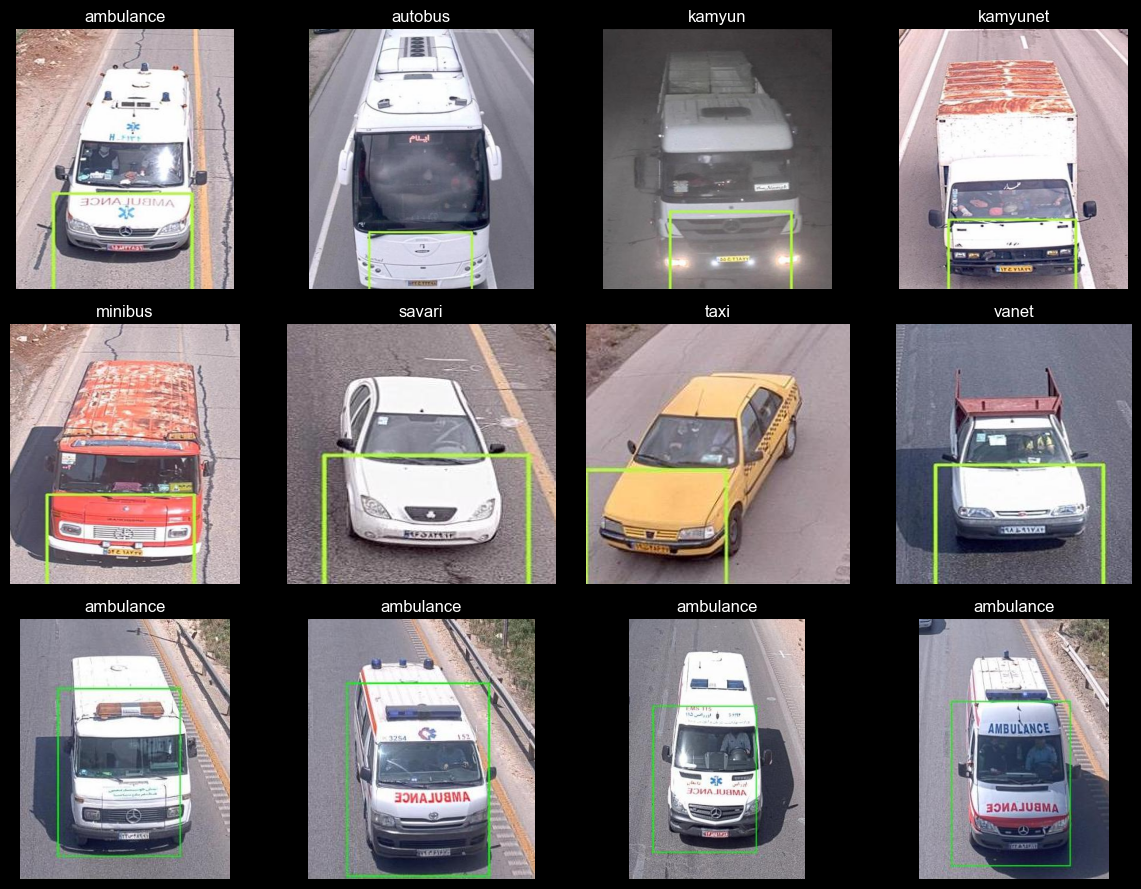

In [74]:
samples = (
    metadata_df[metadata_df["split"] == "train"]
    .groupby("class", group_keys=False)
    .head(1)
)

extra = metadata_df[metadata_df["split"] == "train"].iloc[8:12]
samples = pd.concat([samples, extra])

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    img = Image.open(row["path"])
    ax.imshow(img)
    ax.set_title(row["class"])
    ax.axis("off")

plt.tight_layout()
plt.show()

---
#### check images with hash md5:



In [75]:
def file_hash(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            h.update(chunk)
    return h.hexdigest()

metadata_df["hash"] = metadata_df["path"].apply(file_hash)

In [76]:
metadata_df

,split,class,path,filename,extension,format,width,height,area,hash
0,train,ambulance,..\data\dataset\train\ambulance\195939523.jpg,195939523.jpg,.jpg,JPEG,307,366,112362,729acf5fc1034ec77741e16b50fc95b0
1,train,ambulance,..\data\dataset\train\ambulance\197398569.jpg,197398569.jpg,.jpg,JPEG,300,307,92100,e6342dd87d203adae79690c547ed41e4
2,train,ambulance,..\data\dataset\train\ambulance\198197588.jpg,198197588.jpg,.jpg,JPEG,273,331,90363,37171f26efee91489e759bab458f1d08
3,train,ambulance,..\data\dataset\train\ambulance\198727855.jpg,198727855.jpg,.jpg,JPEG,328,365,119720,5ba6cc623db387180f5fe1520e3ad38e
4,train,ambulance,..\data\dataset\train\ambulance\198860064.jpg,198860064.jpg,.jpg,JPEG,273,335,91455,611e340eac96a33f146cbf040f0caf0a
...,...,...,...,...,...,...,...,...,...,...
3731,train,vanet,..\data\dataset\train\vanet\218955810.jpg,218955810.jpg,.jpg,JPEG,210,264,55440,a5744de44148eebd8f0e7acce251fef5
3732,train,vanet,..\data\dataset\train\vanet\218984817.jpg,218984817.jpg,.jpg,JPEG,198,254,50292,03433010ae8f35ee9f9f4f546bdc1aa5
3733,train,vanet,..\data\dataset\train\vanet\219083209.jpg,219083209.jpg,.jpg,JPEG,162,216,34992,4d60fe09890c8daa9158bb3bd699f6db
3734,train,vanet,..\data\dataset\train\vanet\219088134.jpg,219088134.jpg,.jpg,JPEG,129,180,23220,255a6c9e0763b73d1fb065805cc4b624


In [77]:
duplicates = metadata_df[metadata_df["hash"].duplicated(keep=False)].sort_values("hash")
duplicates[["split", "class", "filename", "hash"]]

,split,class,filename,hash


In [78]:
duplicates.groupby("hash")["class"].nunique().value_counts()

Series([], Name: count, dtype: int64)

In [79]:
conflict_hashes = (
    metadata_df.groupby("hash")["class"].nunique()
)
conflict_hashes = conflict_hashes[conflict_hashes > 1]
print(conflict_hashes)

Series([], Name: class, dtype: int64)


In [80]:
metadata_df.groupby(["split", "class"]).size()

split  class    
train  ambulance    407
       autobus      520
       kamyun       487
       kamyunet     564
       minibus      461
       savari       562
       taxi         535
       vanet        200
dtype: int64

In [81]:
total_pool_df = metadata_df[
    metadata_df["split"].isin(["train"])
].copy()

print(f"total: {len(total_pool_df)}")


train_df, val_df = train_test_split(
    total_pool_df,
    test_size=0.20,
    stratify=train_pool_df["class"],
    random_state=42
)
print(f"train dataset: {len(train_df)}")
print(f"validation dataset: {len(val_df)}")
assert len(train_df) + len(val_df) == len(train_pool_df) , "You have a big problem here.Check it again."

total: 3736
train dataset: 2988
validation dataset: 748


In [82]:
Path("../csv_files").mkdir(parents=True, exist_ok=True)

train_df.to_csv("../csv_files/train_split.csv", index=False)
val_df.to_csv("../csv_files/val_split.csv", index=False)

In [83]:
print("\nClass distribution - training pool:")
print(total_pool_df["class"].value_counts().sort_index())

print("\nClass distribution - train:")
print(train_df["class"].value_counts().sort_index())

print("\nClass distribution - validation:")
print(val_df["class"].value_counts().sort_index())


Class distribution - training pool:
class
ambulance    407
autobus      520
kamyun       487
kamyunet     564
minibus      461
savari       562
taxi         535
vanet        200
Name: count, dtype: int64

Class distribution - train:
class
ambulance    326
autobus      416
kamyun       389
kamyunet     451
minibus      369
savari       449
taxi         428
vanet        160
Name: count, dtype: int64

Class distribution - validation:
class
ambulance     81
autobus      104
kamyun        98
kamyunet     113
minibus       92
savari       113
taxi         107
vanet         40
Name: count, dtype: int64


In [84]:
assert set(train_df["hash"]).isdisjoint(set(val_df["hash"])),"❌ hash overlap between train and validation."

print("✅ No hash overlap between train and validation.")

✅ No hash overlap between train and validation.


In [85]:
train_val_overlap = (
    set(train_df["hash"]) &
    set(val_df["hash"])
)
print(f"train_val_overlap:   {len(train_val_overlap)}")

train_val_overlap:   0


In [87]:
CLEANED_ROOT = DATASET_ROOT / "cleaned"
CLEANED_TRAIN = CLEANED_ROOT / "train"
CLEANED_VAL = CLEANED_ROOT / "val"

classes = sorted(total_pool_df["class"].unique())

assert len(classes) == 8, f"Expected 8 classes, found {len(classes)}: {classes}"

for class_name in classes:
    (CLEANED_TRAIN / class_name).mkdir(parents=True,exist_ok=True)

    (CLEANED_VAL / class_name).mkdir(parents=True,exist_ok=True)


def copy_images(df, destination_root):

    for _, row in df.iterrows():

        source = Path(row["path"])

        class_dir = destination_root / row["class"]

        destination = class_dir / row["filename"]

        if destination.exists():
            destination = (class_dir / f"{row['hash'][:8]}_{row['filename']}")

        shutil.copy2(source, destination)


copy_images(train_df, CLEANED_TRAIN)
copy_images(val_df, CLEANED_VAL)


print("\n✅ Cleaned dataset created.")
print(f"Train folder: {CLEANED_TRAIN}")
print(f"Val folder:   {CLEANED_VAL}")


✅ Cleaned dataset created.
Train folder: ..\data\dataset\cleaned\train
Val folder:   ..\data\dataset\cleaned\val
